In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Load the training data
train_df = pd.read_csv('data/raw/training_codification_data.csv')

## Long tail distributions of code labeling

4,059 unique ICD-10 codes, 47% of them (1,915) correspond to a single disease.

Total rows: 13700
Unique ICD-10 codes: 4059
Codes with only 1 example: 1915


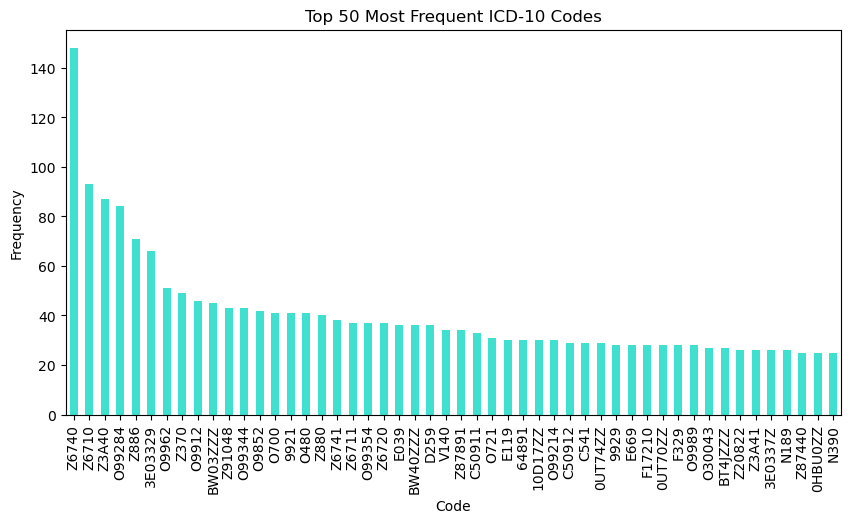

In [2]:
# Calculate code frequency
code_counts = train_df['Code'].value_counts()

print(f"Total rows: {len(train_df)}")
print(f"Unique ICD-10 codes: {len(code_counts)}")
print(f"Codes with only 1 example: {(code_counts == 1).sum()}")

# Plot Top 50 Codes
plt.figure(figsize=(10,5))
code_counts.head(50).plot(kind='bar', color='turquoise')
plt.title('Top 50 Most Frequent ICD-10 Codes')
plt.ylabel('Frequency')
plt.show()

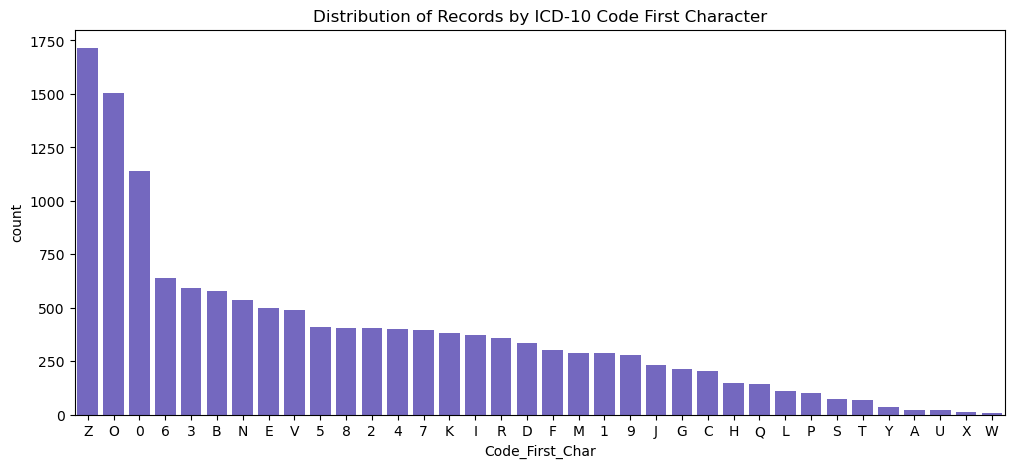

In [3]:
# Extract first character
train_df['Code_First_Char'] = train_df['Code'].str[0]

# Plot distribution of first characters
plt.figure(figsize=(12,5))
sns.countplot(data=train_df, x='Code_First_Char', 
                order=train_df['Code_First_Char'].value_counts().index, color='slateblue')
plt.title('Distribution of Records by ICD-10 Code First Character')
plt.show()

Average words per literal: 2.21
Maximum words in a literal: 9


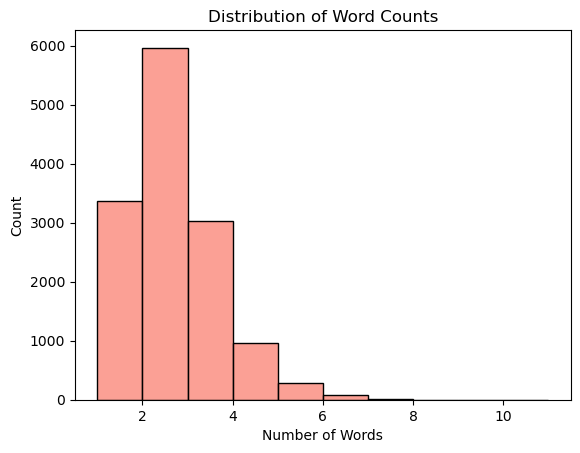

In [4]:
train_df['word_count'] = train_df['Literal'].apply(lambda x: len(x.split()))

print(f"Average words per literal: {train_df['word_count'].mean():.2f}")
print(f"Maximum words in a literal: {train_df['word_count'].max()}")

sns.histplot(train_df['word_count'], bins=range(1, 12), color='salmon')
plt.title('Distribution of Word Counts')
plt.xlabel('Number of Words')
plt.show()

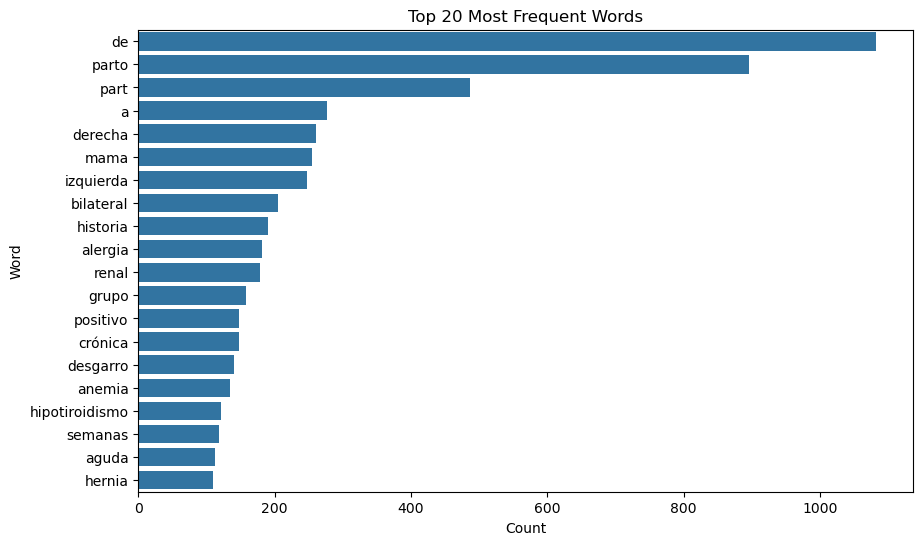

In [5]:
all_words = " ".join(train_df['Literal'].astype(str)).lower().split()
word_freq = Counter(all_words).most_common(20)

word_df = pd.DataFrame(word_freq, columns=['Word', 'Count'])
plt.figure(figsize=(10,6))
sns.barplot(data=word_df, y='Word', x='Count')
plt.title('Top 20 Most Frequent Words')
plt.show()